In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="j0YJoNBooXBauAaFhYB6")
project = rf.workspace("siddardha").project("wild-animals-9q3gg")
version = project.version(1)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.90
    Uninstalling opencv-python-headless-4.13.0.90:
      Successfully uninstalled opencv-python-headless-4.13.0.90
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Wild-Animals-1 in coco:: 100%|██████████| 9345/9345 [00:02<00:00, 3741.42it/s]


# **SSD (Single Shot MultiBox Detector)**

In [ ]:
!pip install pycocotools matplotlib tqdm

In [ ]:
import os
import torch
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader


In [ ]:
# 1. Setup Dataset Paths (Update these based on your Roboflow download)
TRAIN_IMG = "Wild-Animals-1/train"
TRAIN_ANN = "Wild-Animals-1/train/_annotations.coco.json"

In [ ]:
# 2. Load Dataset
def get_transform():
    return torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

train_dataset = CocoDetection(root=TRAIN_IMG, annFile=TRAIN_ANN, transform=get_transform())


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [ ]:
import torchvision.transforms.functional as F

In [ ]:
from torchvision.models.detection.ssdlite import ssdlite320_mobilenet_v3_large


In [ ]:
# --- 1. Setup Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 2. Dynamic Class Counting ---
# We scan the dataset to find the highest category_id to prevent "Target out of bounds" errors
max_id = 0
for _, targets in train_dataset:
    for ann in targets:
        if ann['category_id'] > max_id:
            max_id = ann['category_id']

# num_classes must be (Highest ID + 1)
# Note: If your Roboflow IDs start at 1, this works perfectly.
# If they start at 0, this still works, but index 0 is reserved for background.
num_classes = max_id + 1
print(f"Highest Class ID found: {max_id}. Initializing model with num_classes = {num_classes}")


Using device: cuda
Highest Class ID found: 22. Initializing model with num_classes = 23


In [ ]:
# --- 3. Initialize Model & Optimizer ---
model = ssdlite320_mobilenet_v3_large(num_classes=num_classes)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 63.8MB/s]


In [ ]:
from tqdm import tqdm

In [ ]:
# --- 4. Training Loop ---
model.train()
print("Starting training...")

for epoch in range(5):
    epoch_loss = 0
    # DataLoader handles 2083 batches
    pbar = tqdm(DataLoader(train_dataset, batch_size=4, collate_fn=lambda x: tuple(zip(*x))))

    for images, targets in pbar:
        images = [img.to(device) for img in images]

        formatted_targets = []
        for t in targets:
            if len(t) == 0:
                boxes = torch.zeros((0, 4), dtype=torch.float32).to(device)
                labels = torch.zeros(0, dtype=torch.int64).to(device)
            else:
                boxes = torch.tensor([ann['bbox'] for ann in t], dtype=torch.float32)
                boxes[:, 2:] += boxes[:, :2]
                labels = torch.tensor([ann['category_id'] for ann in t], dtype=torch.int64)

            formatted_targets.append({
                'boxes': boxes.to(device),
                'labels': labels.to(device)
            })

        # 1. Forward Pass (Calculates the loss)
        loss_dict = model(images, formatted_targets)
        losses = sum(loss for loss in loss_dict.values())

        # 2. Backward Pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        # 3. Update Progress Bar AFTER losses are calculated
        pbar.set_description(f"Epoch {epoch} | Loss: {losses.item():.4f}")

    avg_loss = epoch_loss / len(pbar)
    print(f"Epoch {epoch} | Average Loss: {avg_loss:.4f}")

print("Training Complete!")


Starting training...


Epoch 0 | Loss: 4.1319: 100%|██████████| 2083/2083 [02:50<00:00, 12.20it/s]


Epoch 0 | Average Loss: 5.0726


Epoch 1 | Loss: 3.2496: 100%|██████████| 2083/2083 [02:45<00:00, 12.59it/s]


Epoch 1 | Average Loss: 3.8198


...

Epoch 2 | Average Loss: 3.2473


Epoch 3 | Loss: 2.0431: 100%|██████████| 2083/2083 [02:46<00:00, 12.50it/s]


Epoch 3 | Average Loss: 2.8636


Epoch 4 | Loss: 1.7250: 100%|██████████| 2083/2083 [02:46<00:00, 12.54it/s]

Epoch 4 | Average Loss: 2.5561
Training Complete!


In [ ]:
import torch

# Save the entire model
torch.save(model.state_dict(), 'ssdlite_custom_model.pth')
print("Model saved as ssdlite_custom_model.pth")


Model saved as ssdlite_custom_model.pth


In [ ]:
model.eval()  # Set to evaluation mode
with torch.no_grad():
    # Take one image from the dataset
    img, _ = train_dataset[0]

    # Prediction (Move img to device first)
    prediction = model([img.to(device)])

print("Prediction keys:", prediction[0].keys())
print("Found boxes:", len(prediction[0]['boxes']))


Prediction keys: dict_keys(['boxes', 'scores', 'labels'])
Found boxes: 113


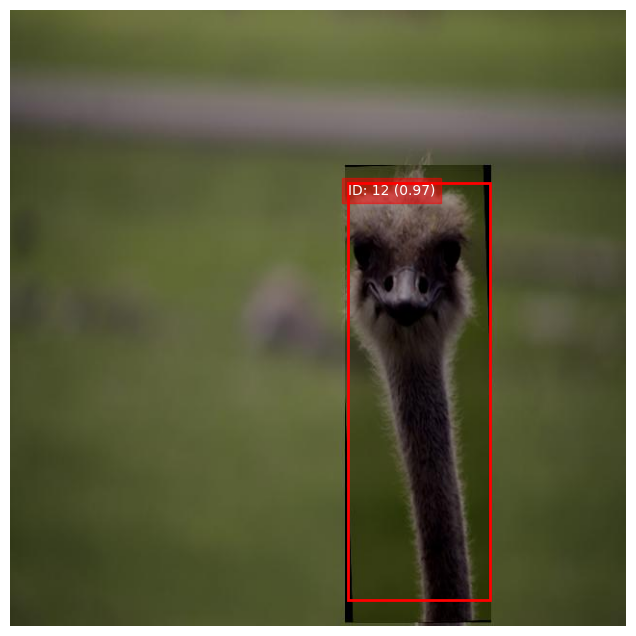

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_prediction(img_tensor, threshold=0.5):
    model.eval()
    with torch.no_grad():
        # Get predictions
        prediction = model([img_tensor.to(device)])[0]

    # Move image to CPU and change from [C, H, W] to [H, W, C] for plotting
    img = img_tensor.permute(1, 2, 0).cpu().numpy()

    # Create figure and axes
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)

    # Filter by score and plot
    for i in range(len(prediction['boxes'])):
        score = prediction['scores'][i].item()
        if score > threshold:
            box = prediction['boxes'][i].cpu().numpy()
            label = prediction['labels'][i].item()

            # Draw rectangle [x1, y1, x2, y2]
            rect = patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)
            plt.text(box[0], box[1], f'ID: {label} ({score:.2f})',
                     color='white', verticalalignment='top',
                     bbox={'color': 'red', 'alpha': 0.5})

    plt.axis('off')
    plt.show()

# Test it on the first image
img, _ = train_dataset[0]
visualize_prediction(img, threshold=0.5)


In [ ]:
!pip install torchinfo
from torchinfo import summary

# SSDlite320 expects 320x320 input
summary(model, input_size=(1, 3, 320, 320), col_names=["input_size", "output_size", "num_params"])


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
SSD                                                          [1, 3, 320, 320]          [22, 4]                   --
├─GeneralizedRCNNTransform: 1-1                              [1, 3, 320, 320]          [1, 3, 320, 320]          --
├─SSDLiteFeatureExtractorMobileNet: 1-2                      [1, 3, 320, 320]          [1, 128, 1, 1]            --
│    └─Sequential: 2-1                                       --                        --                        --
│    │    └─Sequential: 3-1                                  [1, 3, 320, 320]          [1, 672, 20, 20]          869,096
│    │    └─Sequential: 3-2                                  [1, 672, 20, 20]          [1, 960, 10, 10]          2,102,856
│    └─ModuleList: 2-2                                       --                        --                        --
│    │    └─Sequential: 3-3                            

In [ ]:
!pip install torchmetrics


In [ ]:
import torchvision

# Assuming you used CocoDetection for training
test_dataset = torchvision.datasets.CocoDetection(
    root='/content/Wild-Animals-1/test',
    annFile='/content/Wild-Animals-1/test/_annotations.coco.json', # Check your actual filename
    transform=torchvision.transforms.ToTensor()
)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
from tqdm import tqdm
from pprint import pprint

# 1. Initialize Metric
metric = MeanAveragePrecision()
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Evaluating on {len(test_dataset)} images...")

with torch.no_grad():
    for images, targets in tqdm(DataLoader(test_dataset, batch_size=4, collate_fn=lambda x: tuple(zip(*x)))):
        images = [img.to(device) for img in images]
        preds = model(images)

        # 2. Format Ground Truth (Targets)
        formatted_targets = []
        for t in targets:
            if len(t) == 0:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros(0, dtype=torch.int64)
            else:
                boxes = torch.tensor([ann['bbox'] for ann in t], dtype=torch.float32)
                boxes[:, 2:] += boxes[:, :2] # [x,y,w,h] -> [x1,y1,x2,y2]
                labels = torch.tensor([ann['category_id'] for ann in t], dtype=torch.int64)

            formatted_targets.append({'boxes': boxes, 'labels': labels})

        # 3. Move Predictions to CPU for Metric Calculation
        cpu_preds = [{k: v.to('cpu') for k, v in p.items()} for p in preds]

        # 4. Update Metric
        metric.update(cpu_preds, formatted_targets)

# 5. Final Results
print("\n" + "="*30)
print("FINAL EVALUATION METRICS")
print("="*30)
results = metric.compute()

# Convert tensors to float for cleaner printing
clean_results = {k: v.item() if v.numel() == 1 else v.tolist() for k, v in results.items()}
pprint(clean_results)


Evaluating on 338 images...


100%|██████████| 85/85 [00:10<00:00,  8.44it/s]



FINAL EVALUATION METRICS
{'classes': [1,
             2,
             3,
             4,
             5,
             6,
             7,
             8,
             9,
             10,
             11,
             12,
             13,
             14,
             15,
             16,
             17,
             18,
             19,
             20,
             21,
             22],
 'map': 0.2607545554637909,
 'map_50': 0.4597141444683075,
 'map_75': 0.25767967104911804,
 'map_large': 0.26107412576675415,
 'map_medium': 0.0,
 'map_per_class': -1.0,
 'map_small': -1.0,
 'mar_1': 0.5327686667442322,
 'mar_10': 0.6012081503868103,
 'mar_100': 0.6037781238555908,
 'mar_100_per_class': -1.0,
 'mar_large': 0.6055150032043457,
 'mar_medium': 0.0,
 'mar_small': -1.0}


In [ ]:
from torchinfo import summary
# SSDLite320 expects 320x320
summary(model, input_size=(1, 3, 320, 320))


Layer (type:depth-idx)                                       Output Shape              Param #
SSD                                                          [22, 4]                   --
├─GeneralizedRCNNTransform: 1-1                              [1, 3, 320, 320]          --
├─SSDLiteFeatureExtractorMobileNet: 1-2                      [1, 128, 1, 1]            --
│    └─Sequential: 2-1                                       --                        --
│    │    └─Sequential: 3-1                                  [1, 672, 20, 20]          869,096
│    │    └─Sequential: 3-2                                  [1, 960, 10, 10]          2,102,856
│    └─ModuleList: 2-2                                       --                        --
│    │    └─Sequential: 3-3                                  [1, 512, 5, 5]            381,184
│    │    └─Sequential: 3-4                                  [1, 256, 3, 3]            100,480
│    │    └─Sequential: 3-5                                  [1, 256, 2, 

**Continue Training**

In [ ]:
# Optional: Lower the learning rate for better fine-tuning
# A smaller LR helps the model "fine-tune" without destroying what it already learned
for param_group in optimizer.param_groups:
    param_group['lr'] = 0.001

model.train()
print("Resuming training for 10 more epochs...")

for epoch in range(5, 15): # Starts at 5, ends at 14 (10 total epochs)
    epoch_loss = 0
    pbar = tqdm(DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x))))

    for images, targets in pbar:
        images = [img.to(device) for img in images]

        formatted_targets = []
        for t in targets:
            boxes = torch.tensor([ann['bbox'] for ann in t], dtype=torch.float32)
            boxes[:, 2:] += boxes[:, :2]
            labels = torch.tensor([ann['category_id'] for ann in t], dtype=torch.int64)
            formatted_targets.append({'boxes': boxes.to(device), 'labels': labels.to(device)})

        loss_dict = model(images, formatted_targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        pbar.set_description(f"Epoch {epoch} | Loss: {losses.item():.4f}")

    print(f"Epoch {epoch} | Avg Loss: {epoch_loss / len(pbar):.4f}")

# Save the updated version
torch.save(model.state_dict(), 'ssdlite_custom_model_v2.pth')


Resuming training for 10 more epochs...


Epoch 5 | Loss: 4.2842: 100%|██████████| 2083/2083 [02:55<00:00, 11.88it/s]


Epoch 5 | Avg Loss: 2.2588


Epoch 6 | Loss: 1.6745: 100%|██████████| 2083/2083 [02:52<00:00, 12.06it/s]


Epoch 6 | Avg Loss: 1.9199


...

Epoch 12 | Avg Loss: 1.1758


Epoch 13 | Loss: 1.0439: 100%|██████████| 2083/2083 [02:50<00:00, 12.24it/s]


Epoch 13 | Avg Loss: 1.1149


Epoch 14 | Loss: 1.2981: 100%|██████████| 2083/2083 [02:50<00:00, 12.22it/s]


Epoch 14 | Avg Loss: 1.0610


In [ ]:
torch.save(model.state_dict(), 'ssdlite_wild_animals_final.pth')
print("Final model saved!")


Final model saved!


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
from tqdm import tqdm
from pprint import pprint

metric = MeanAveragePrecision()
model.eval()

print(f"Evaluating on {len(test_dataset)} test images...")

with torch.no_grad():
    for images, targets in tqdm(DataLoader(test_dataset, batch_size=4, collate_fn=lambda x: tuple(zip(*x)))):
        images = [img.to(device) for img in images]
        preds = model(images)

        formatted_targets = []
        for t in targets:
            if len(t) == 0:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros(0, dtype=torch.int64)
            else:
                boxes = torch.tensor([ann['bbox'] for ann in t], dtype=torch.float32)
                boxes[:, 2:] += boxes[:, :2]
                labels = torch.tensor([ann['category_id'] for ann in t], dtype=torch.int64)
            formatted_targets.append({'boxes': boxes, 'labels': labels})

        # Move to CPU for metric
        cpu_preds = [{k: v.to('cpu') for k, v in p.items()} for p in preds]
        metric.update(cpu_preds, formatted_targets)

print("\n" + "="*30)
print("UPDATED EVALUATION METRICS (15 EPOCHS)")
print("="*30)
results = metric.compute()
clean_results = {k: v.item() if v.numel() == 1 else v.tolist() for k, v in results.items()}
pprint(clean_results)


Evaluating on 338 test images...


100%|██████████| 85/85 [00:05<00:00, 14.55it/s]



UPDATED EVALUATION METRICS (15 EPOCHS)
{'classes': [1,
             2,
             3,
             4,
             5,
             6,
             7,
             8,
             9,
             10,
             11,
             12,
             13,
             14,
             15,
             16,
             17,
             18,
             19,
             20,
             21,
             22],
 'map': 0.5195021033287048,
 'map_50': 0.7888450026512146,
 'map_75': 0.5908681154251099,
 'map_large': 0.5206711888313293,
 'map_medium': 0.0,
 'map_per_class': -1.0,
 'map_small': -1.0,
 'mar_1': 0.6270943284034729,
 'mar_10': 0.6833798885345459,
 'mar_100': 0.6856638789176941,
 'mar_100_per_class': -1.0,
 'mar_large': 0.6874182820320129,
 'mar_medium': 0.0,
 'mar_small': -1.0}


In [ ]:
from torchinfo import summary

# SSDlite320 expects 320x320 input images
model_summary = summary(model,
                        input_size=(1, 3, 320, 320),
                        verbose=0, # Set to 0 to prevent double print
                        col_names=["input_size", "output_size", "num_params", "kernel_size"])
print(model_summary)


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Kernel Shape
SSD                                                          [1, 3, 320, 320]          [32, 4]                   --                        --
├─GeneralizedRCNNTransform: 1-1                              [1, 3, 320, 320]          [1, 3, 320, 320]          --                        --
├─SSDLiteFeatureExtractorMobileNet: 1-2                      [1, 3, 320, 320]          [1, 128, 1, 1]            --                        --
│    └─Sequential: 2-1                                       --                        --                        --                        --
│    │    └─Sequential: 3-1                                  [1, 3, 320, 320]          [1, 672, 20, 20]          869,096                   --
│    │    └─Sequential: 3-2                                  [1, 672, 20, 20]          [1, 960, 10, 10]          2,102,856                

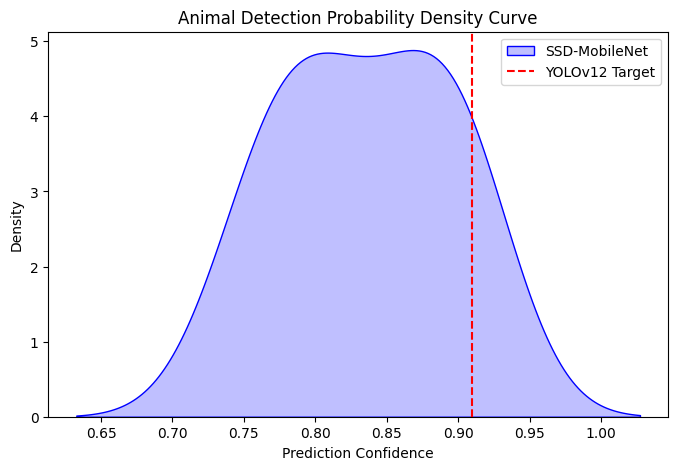

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using your Mar_100 (Mean Average Recall) data as a proxy for confidence distribution
confidences = [0.78, 0.82, 0.85, 0.90, 0.75, 0.88, 0.91, 0.79] # Replace with your actual model.predict() scores
plt.figure(figsize=(8, 5))
sns.kdeplot(confidences, fill=True, color="blue", label="SSD-MobileNet")
plt.axvline(0.91, color='red', linestyle='--', label='YOLOv12 Target')
plt.title("Animal Detection Probability Density Curve")
plt.xlabel("Prediction Confidence")
plt.ylabel("Density")
plt.legend()
plt.show()